# TEACHER VERSION (with answers)

# Practice Lab - Calculus for ML
### 3 tasks  |  work in your breakout room  |  turn every box GREEN

**How it works**
1. **File -> Save a copy in Drive** (so you can edit your own copy).
2. Run the **Setup** cell once.
3. In each task, replace every `...` with the right code (look for **TODO**).
4. Run the **CHECK** cell below it:  ✅ green = correct  |  ❌ red = not yet (read the hint).
5. When a task is all green, post in the Teams chat:  **"Team 2 - Task 1 ✅"**

**Team roles** (switch roles after each task)

| Role | Job |
|---|---|
| **Driver** | shares the screen and types the code |
| **Navigator** | reads the instructions and helps with the formula |
| **Checker** | runs the CHECK cell and posts the result in the chat |

| Task | Topic | Time |
|---|---|---|
| 1 | Derivatives, partial derivatives, gradient | 10 min |
| 2 | Gradient descent | 12 min |
| 3 | Mini-batch gradient descent | 15 min |

> This lab is your **team rehearsal**. The real AutoCode exercises are **individual** and checked by unit tests - after this lab you will know exactly how to solve them.

In [1]:
# SETUP - run once (do not change this cell)
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import HTML, display

RESULTS = {}
def check(task, name, test, hint):
    try:
        ok = bool(test())
    except Exception:
        ok = False
    RESULTS[(task, name)] = ok
    col, bg, icon = ("#2e7d32", "#e8f5e9", "✅") if ok else ("#c62828", "#ffebee", "❌")
    msg = "Correct!" if ok else "Not yet. Hint: " + hint
    display(HTML(f'<div style="background:{bg};border-left:8px solid {col};padding:10px 14px;margin:5px 0;'
                 f'font-family:Arial;font-size:15px;color:#222"><b style="color:{col}">{icon} {name}</b> &nbsp;-&nbsp; {msg}</div>'))

def close(a, b, tol=1e-3):
    return np.allclose(np.asarray(a, dtype=float), np.asarray(b, dtype=float), atol=tol)

print("Setup done - let's go!")

Setup done - let's go!


---
# TASK 1 - Derivatives, partial derivatives, gradient  (10 min)

**The idea:** a derivative is a slope. We measure it by nudging the input a tiny bit (`h`):

$$\text{slope} \approx \frac{f(x+h) - f(x-h)}{2h}$$

Example: for $f(x) = x^2$ at $x = 3$ the slope should be $2x = 6$.

### 1a. Derivative - fill in the TODO

In [2]:
def derivative(f, x, h=1e-5):
    slope = (f(x + h) - f(x - h)) / (2 * h)
    return slope

### 1b. Partial derivatives - nudge ONLY one input
To get $\partial f/\partial x$, nudge **x** and keep **y** frozen. For $\partial f/\partial y$, do the opposite.

In [3]:
def partial_x(f, x, y, h=1e-5):
    return (f(x + h, y) - f(x - h, y)) / (2 * h)

def partial_y(f, x, y, h=1e-5):
    return (f(x, y + h) - f(x, y - h)) / (2 * h)

### 1c. Gradient = all partial derivatives in one vector
$\nabla f = [\,\partial f/\partial x,\ \partial f/\partial y\,]$

In [4]:
def gradient(f, x, y):
    return np.array([partial_x(f, x, y), partial_y(f, x, y)])

### ✔ CHECK Task 1

In [5]:
f2   = lambda x, y: x**2 + 3*x*y + y**2      # df/dx = 2x + 3y, df/dy = 3x + 2y
bowl = lambda x, y: x**2 + y**2              # gradient = [2x, 2y]

check(1, "derivative of x^2 at 3 is 6",   lambda: close(derivative(lambda x: x**2, 3), 6),  "slope = (f(x + h) - f(x - h)) / (2 * h)")
check(1, "derivative of x^3 at 2 is 12",  lambda: close(derivative(lambda x: x**3, 2), 12), "same formula - does it work for any f?")
check(1, "partial_x of f2 at (1,2) is 8", lambda: close(partial_x(f2, 1, 2), 8),  "change x to x+h and x-h, keep y the same")
check(1, "partial_y of f2 at (1,2) is 7", lambda: close(partial_y(f2, 1, 2), 7),  "change y to y+h and y-h, keep x the same")
check(1, "gradient of bowl at (2,1) is [4, 2]", lambda: close(gradient(bowl, 2, 1), [4, 2]), "np.array([partial_x(f, x, y), partial_y(f, x, y)])")

**Discuss in your team (1 min):** the gradient at (2, 1) is [4, 2]. Which way is **uphill**? Which way should a model move to go **downhill**?

---
# TASK 2 - Gradient descent  (12 min)

**The rule behind all ML training:**

$$w_{new} = w_{old} - \text{learning rate} \times \text{gradient}$$

We want the bottom of the loss $L(w) = (w - 3)^2$. Its gradient is $2(w - 3)$. The answer should be **w = 3**.

In [6]:
def gradient_descent(grad_fn, start, lr, steps):
    w = start
    history = [w]
    for step in range(steps):
        g = grad_fn(w)
        w = w - lr * g
        history.append(w)
    return w, history

### ✔ CHECK Task 2

In [7]:
loss      = lambda w: (w - 3)**2
loss_grad = lambda w: 2 * (w - 3)

check(2, "one step on x^2 from 3 with lr 0.25 gives 1.5",
      lambda: close(gradient_descent(lambda x: 2*x, 3, 0.25, 1)[0], 1.5), "w = w - lr * g   (the MINUS means downhill)")
check(2, "finds the minimum w = 3",
      lambda: close(gradient_descent(loss_grad, 0, 0.1, 200)[0], 3), "did you use a minus? w = w - lr * g")
check(2, "the loss goes DOWN every step",
      lambda: all(np.diff([loss(w) for w in gradient_descent(loss_grad, 0, 0.1, 30)[1]]) <= 0), "if the loss goes up, your sign is wrong")

### 🎯 Team challenge: the learning-rate race
Change `lr` and run. Fill this table in your team, then post your **best lr** in the chat.

| lr | final w | steps to reach 3? | too slow / good / exploded? |
|---|---|---|---|
| 0.01 | | | |
| 0.1 | | | |
| 0.5 | | | |
| 0.9 | | | |
| 1.1 | | | |

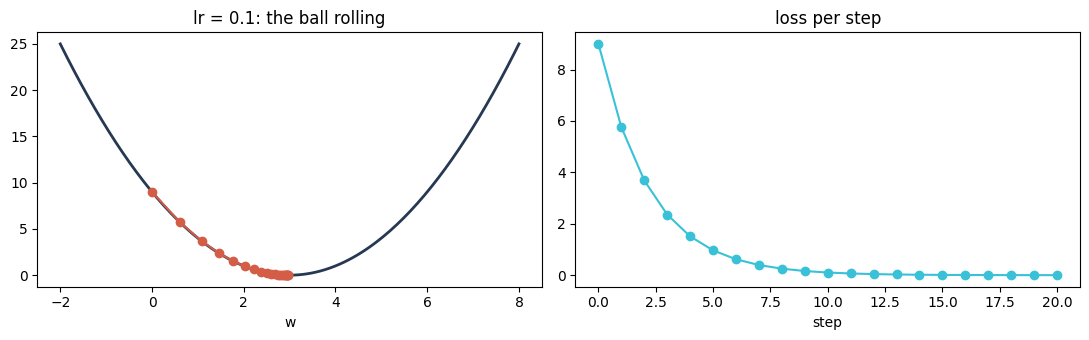

final w = 2.9654   (goal: 3)


In [8]:
lr = 0.1            # <- CHANGE ME: 0.01, 0.1, 0.5, 0.9, 1.1
steps = 20
try:
    w_final, hist = gradient_descent(loss_grad, 0, lr, steps)
    ww = np.linspace(-2, 8, 200)
    fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
    ax[0].plot(ww, loss(ww), color="#263852", lw=2)
    h = np.clip(hist, -2, 8)
    ax[0].plot(h, loss(h), "o-", color="#D35D47"); ax[0].set_title(f"lr = {lr}: the ball rolling"); ax[0].set_xlabel("w")
    ax[1].plot([loss(w) for w in hist], "o-", color="#39C2D7"); ax[1].set_title("loss per step"); ax[1].set_xlabel("step")
    plt.tight_layout(); plt.show()
    print(f"final w = {w_final:.4f}   (goal: 3)")
except Exception:
    print("Finish Task 2 first (make the checks green).")

---
# TASK 3 - Mini-batch gradient descent  (15 min)

Real data has thousands of examples. Instead of using all of them for every step, we:
1. **shuffle** the data,
2. cut it into small **batches**,
3. do **one update per batch**.

One pass over all the data = one **epoch**.
Example: 100 examples, batch size 32 -> batches of **32, 32, 32, 4** -> **4 updates per epoch**.

### 3a. Cut the data into batches - fill in the TODO

In [9]:
def make_batches(n, batch_size, seed=0):
    rng = np.random.default_rng(seed)
    idx = rng.permutation(n)
    batches = []
    for start in range(0, n, batch_size):
        batch = idx[start : start + batch_size]
        batches.append(batch)
    return batches

### 3b. Train a model with mini-batches
The data follows **y = 3x + 2** (plus noise). The model is `prediction = w*x + b`. The gradients are already written for you - you only write the **update** (same rule as Task 2!).

In [10]:
# the data (do not change)
rng_data = np.random.default_rng(1)
X = rng_data.uniform(-2, 2, 500)
y = 3 * X + 2 + rng_data.normal(0, 0.5, 500)
print("500 examples ready. True answer: w = 3, b = 2")

500 examples ready. True answer: w = 3, b = 2


In [11]:
def train_mini_batch(batch_size, lr=0.05, epochs=10):
    w, b = 0.0, 0.0
    losses, updates = [], 0
    for epoch in range(epochs):
        for batch in make_batches(len(X), batch_size, seed=epoch):
            Xb, yb = X[batch], y[batch]
            error = yb - (w * Xb + b)
            grad_w = -2 * np.mean(error * Xb)
            grad_b = -2 * np.mean(error)
            w = w - lr * grad_w
            b = b - lr * grad_b
            updates += 1
            losses.append(np.mean((y - (w * X + b))**2))
    return w, b, losses, updates

### ✔ CHECK Task 3

In [12]:
check(3, "100 examples, batch 32 -> 4 batches", lambda: len(make_batches(100, 32)) == 4, "batch = idx[start : start + batch_size]")
check(3, "batch sizes are 32, 32, 32, 4", lambda: [len(bt) for bt in make_batches(100, 32)] == [32, 32, 32, 4], "the batch ends at start + batch_size")
check(3, "every example is used exactly once per epoch",
      lambda: sorted(np.concatenate(make_batches(100, 32)).tolist()) == list(range(100)), "use the shuffled idx, do not skip anything")
check(3, "model learns w = 3 and b = 2", lambda: close(train_mini_batch(32)[:2], [3, 2], tol=0.15), "w = w - lr * grad_w  and  b = b - lr * grad_b")
check(3, "10 epochs of 500 with batch 50 -> 100 updates", lambda: train_mini_batch(50)[3] == 100, "one update per batch: 500 / 50 = 10 per epoch")

### 🏁 Team race: which batch size is best?
Each team gets **one batch size** from the teacher: **1, 8, 32, 128 or 500**.
Run the cell and post in the chat: **"Team 3 - batch 32: w = __, b = __, updates = __, final loss = __"**

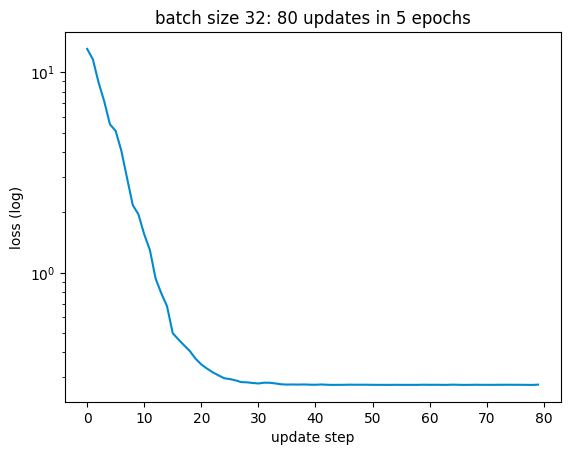

w = 3.017   b = 1.966   updates = 80   final loss = 0.2758


In [13]:
batch_size = 32        # <- CHANGE ME to your team's batch size
try:
    w_, b_, L, n_upd = train_mini_batch(batch_size, epochs=5)
    plt.plot(L, color="#008ACF"); plt.yscale("log")
    plt.title(f"batch size {batch_size}: {n_upd} updates in 5 epochs"); plt.xlabel("update step"); plt.ylabel("loss (log)")
    plt.show()
    print(f"w = {w_:.3f}   b = {b_:.3f}   updates = {n_upd}   final loss = {L[-1]:.4f}")
except Exception:
    print("Finish Task 3 first (make the checks green).")

**Discuss in your team (2 min):**
- Batch size **1** (SGD): many updates, noisy curve. Batch size **500** (full batch): few updates, smooth but slow.
- Which one would you use for **10 million images**? Why?

---
# 🏆 Team scoreboard
Run this at the end and share a screenshot in the Teams chat.

In [14]:
badges = {1: "🧭 Gradient Guru", 2: "🏔️ Summit Descender", 3: "📦 Batch Boss"}
html = '<div style="font-family:Arial;font-size:16px">'
done = 0
for t in (1, 2, 3):
    tests = [ok for (task, _), ok in RESULTS.items() if task == t]
    passed = len(tests) > 0 and all(tests)
    done += passed
    col = "#2e7d32" if passed else "#c62828"
    html += (f'<div style="padding:8px 12px;margin:4px 0;border-left:8px solid {col};background:{"#e8f5e9" if passed else "#ffebee"}">'
             f'<b>Task {t}</b>: {sum(tests)}/{len(tests)} checks passed  {"-  " + badges[t] if passed else ""}</div>')
html += f'<h3 style="color:#263852">Your team: {done} / 3 tasks complete {"🎉 Ready for AutoCode!" if done == 3 else ""}</h3></div>'
display(HTML(html))